# Stage 1 — Dabbler Classifier

Per-user, static binary classifier. Predicts `came_back = 1` if a user observed in weeks 0–2 returns to Lernnavi in week 3 or later — the *dabbler* vs *continuing-learner* split that motivates the second-stage research.



## Setup

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

import lightgbm as lgb

DATA_DIR    = Path("data")
OUT_DATASET = DATA_DIR / "stage1.csv.gz"
OUT_PREDS   = DATA_DIR / "stage1_preds.csv.gz"

if not OUT_DATASET.exists():
    raise FileNotFoundError(
        f"{OUT_DATASET} not found. Run `stage_1_data.ipynb` first to build it."
    )

## Load the dataset


In [3]:
df = pd.read_csv(OUT_DATASET)
feature_cols = [c for c in df.columns if c not in ("user_id", "came_back")]
print(f"rows: {len(df):,}  features: {len(feature_cols)}")
print(f"came_back rate: {df['came_back'].mean():.3f}")
df.head()

rows: 22,466  features: 88
came_back rate: 0.608


,user_id,total_events_0_2,n_active_days_0_2,n_click_events_0_2,n_view_events_0_2,n_sessions_0_2,n_topics_event_0_2,mean_hour_0_2,std_hour_0_2,total_transactions_0_2,...,school_Passerelle,school_Passerelle BM/FM,school_Sekundarschule P,school_UG,school_Unknown,school_Vorkurs PH für Berufsleute,school_Vorkurs Pädagogik,school_WMS,school_andere,came_back
0,387604,2.0,2.0,0.0,2.0,0.0,0.0,9.000000,5.656854,2,...,0,0,0,0,1,0,0,0,0,1
1,387605,12.0,1.0,7.0,5.0,2.0,2.0,6.000000,0.000000,5,...,0,0,0,0,1,0,0,0,0,1
2,387608,101.0,2.0,35.0,66.0,2.0,1.0,8.603960,1.225391,34,...,0,0,0,0,1,0,0,0,0,1
3,387613,11.0,1.0,3.0,8.0,1.0,1.0,12.000000,0.000000,2,...,0,0,0,0,1,0,0,0,0,1
4,387615,348.0,6.0,76.0,272.0,2.0,1.0,9.784483,2.961246,37,...,0,0,0,0,0,0,0,0,0,1


## Train / val / test split

Stratified by label since this is per-user classification.

In [4]:
train_val_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["came_back"]
)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, random_state=42, stratify=train_val_df["came_back"]
)
print("train:", train_df.shape, "  val:", val_df.shape, "  test:", test_df.shape)

train: (14377, 90)   val: (3595, 90)   test: (4494, 90)


## LightGBM

In [5]:
model_lgb = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
    n_jobs=1,
    verbose=-1,
)

model_lgb.fit(
    train_df[feature_cols], train_df["came_back"],
    eval_set=[(val_df[feature_cols], val_df["came_back"])],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=True)],
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[217]	valid_0's auc: 0.775217	valid_0's binary_logloss: 0.568183


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Tune the decision threshold on the validation set, then report on the test set

In [6]:
val_p = model_lgb.predict_proba(val_df[feature_cols])[:, 1]
test_p = model_lgb.predict_proba(test_df[feature_cols])[:, 1]

best_f1, best_t = 0.0, 0.5
for t in np.linspace(0.1, 0.9, 50):
    f1 = f1_score(val_df["came_back"], (val_p > t).astype(int))
    if f1 > best_f1:
        best_f1, best_t = f1, t
print(f"Val best threshold: {best_t:.3f}  (val F1 = {best_f1:.4f})")

test_yhat = (test_p > best_t).astype(int)
print(f"\nTest ROC-AUC:   {roc_auc_score(test_df['came_back'], test_p):.4f}")
print(f"Test F1:        {f1_score(test_df['came_back'], test_yhat):.4f}")
print(f"Test Precision: {precision_score(test_df['came_back'], test_yhat):.4f}")
print(f"Test Recall:    {recall_score(test_df['came_back'], test_yhat):.4f}")

print("\nConfusion matrix (rows = true, cols = pred):")
print(confusion_matrix(test_df["came_back"], test_yhat))

print("\nClassification report:")
print(classification_report(
    test_df["came_back"], test_yhat,
    target_names=["left", "came_back"],
))

Val best threshold: 0.296  (val F1 = 0.7909)

Test ROC-AUC:   0.7658
Test F1:        0.7846
Test Precision: 0.6741
Test Recall:    0.9385

Confusion matrix (rows = true, cols = pred):
[[ 524 1239]
 [ 168 2563]]

Classification report:
              precision    recall  f1-score   support

        left       0.76      0.30      0.43      1763
   came_back       0.67      0.94      0.78      2731

    accuracy                           0.69      4494
   macro avg       0.72      0.62      0.61      4494
weighted avg       0.71      0.69      0.64      4494



### Feature importances (LightGBM gain)

Top 15 by gain:
class_year                        7525.0
n_active_days_0_2                 6040.0
mean_hour_0_2                     4338.0
canton_SG                         3623.0
review_rate_0_2                   2918.0
time_between_sessions_mean_0_2    2280.0
avg_response_time_0_2             2121.0
mean_evaluation_score_0_2         2064.0
study                             2028.0
session_duration_mean_0_2         1934.0
std_hour_0_2                      1798.0
retry_ratio_0_2                   1670.0
std_response_time_0_2             1561.0
partial_rate_0_2                  1444.0
n_view_events_0_2                 1424.0


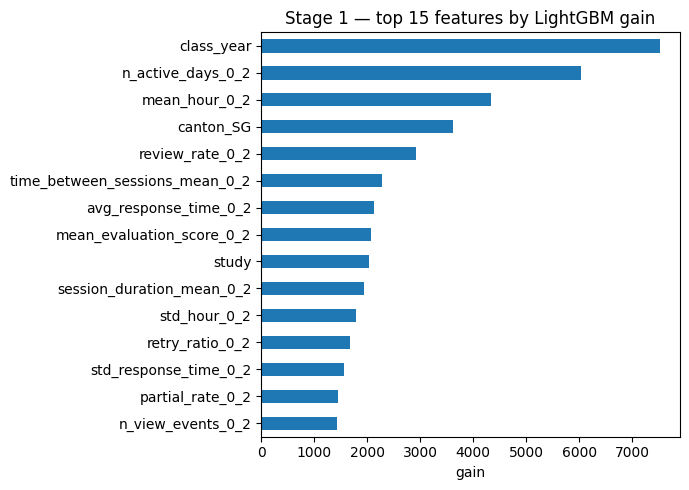

In [7]:
imp = pd.Series(
    model_lgb.booster_.feature_importance(importance_type="gain"),
    index=feature_cols,
).sort_values(ascending=False)

print("Top 15 by gain:")
print(imp.head(15).round(0).to_string())

fig, ax = plt.subplots(figsize=(7, 5))
imp.head(15).iloc[::-1].plot.barh(ax=ax)
ax.set_title("Stage 1 \u2014 top 15 features by LightGBM gain")
ax.set_xlabel("gain")
plt.tight_layout()
plt.show()

## Feature-set ablation

Stage 1 extends `preprocess.ipynb`'s baseline with 8 additional behavioural features 

**Cumulative ablation** — start from baseline, add one group at a time. Shows where the AUC lift accrues.

In [8]:
GROUP_BASELINE = [
    "total_events_0_2", "n_active_days_0_2", "mean_hour_0_2",
    "n_click_events_0_2", "n_view_events_0_2",
    "n_sessions_0_2", "n_topics_event_0_2",
    "total_transactions_0_2",
    "correct_rate_0_2", "partial_rate_0_2", "mean_evaluation_score_0_2",
    "avg_response_time_0_2", "n_topics_transaction_0_2", "n_documents_0_2",
]
GROUP_ADDITIONAL = [
    # Std twins — Swamy, Marras, Käser L@S 2022
    "std_hour_0_2", "std_evaluation_score_0_2", "std_response_time_0_2",
    # Session shape — Chen & Cui 2020
    "session_duration_mean_0_2", "session_duration_std_0_2",
    "time_between_sessions_mean_0_2",
    # Wheel-spinning / engagement ratios — Beck & Gong 2013
    "retry_ratio_0_2", "review_rate_0_2",
]

_NAMED = set(GROUP_BASELINE) | set(GROUP_ADDITIONAL)
GROUP_DEMOGRAPHICS = [c for c in feature_cols if c not in _NAMED]

print(f"  baseline:     {len(GROUP_BASELINE):3d}")
print(f"  additional:   {len(GROUP_ADDITIONAL):3d}")
print(f"  demographics: {len(GROUP_DEMOGRAPHICS):3d}")
total = len(GROUP_BASELINE) + len(GROUP_ADDITIONAL) + len(GROUP_DEMOGRAPHICS)
print(f"  TOTAL:        {total:3d}  (== {len(feature_cols)} feature_cols)")

  baseline:      14
  additional:     8
  demographics:  66
  TOTAL:         88  (== 88 feature_cols)


In [9]:
def run_lgbm(cols, label="run"):
    """Train one LightGBM on `cols`, val-tune the F1 threshold, return test metrics."""
    m = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6, num_leaves=31,
        class_weight="balanced", random_state=42, n_jobs=1, verbose=-1,
    )
    m.fit(
        train_df[cols], train_df["came_back"],
        eval_set=[(val_df[cols], val_df["came_back"])],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    val_pp = m.predict_proba(val_df[cols])[:, 1]
    test_pp = m.predict_proba(test_df[cols])[:, 1]

    best_f1, best_t = 0.0, 0.5
    for t in np.linspace(0.1, 0.9, 50):
        f1 = f1_score(val_df["came_back"], (val_pp > t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    test_yhat = (test_pp > best_t).astype(int)

    return {
        "set": label,
        "n_features": len(cols),
        "test_roc_auc": roc_auc_score(test_df["came_back"], test_pp),
        "test_f1": f1_score(test_df["came_back"], test_yhat),
        "test_precision": precision_score(test_df["came_back"], test_yhat),
        "test_recall": recall_score(test_df["came_back"], test_yhat),
    }

In [10]:
def run_lr(cols, label="run"):
    """Train Logistic Regression on `cols` (StandardScaler-fit per ablation row), val-tune the F1 threshold, return test metrics."""
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[cols])
    X_val   = scaler.transform(val_df[cols])
    X_test  = scaler.transform(test_df[cols])

    lr = LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42,
    )
    lr.fit(X_train, train_df["came_back"])
    val_pp  = lr.predict_proba(X_val)[:, 1]
    test_pp = lr.predict_proba(X_test)[:, 1]

    best_f1, best_t = 0.0, 0.5
    for t in np.linspace(0.1, 0.9, 50):
        f1 = f1_score(val_df["came_back"], (val_pp > t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    test_yhat = (test_pp > best_t).astype(int)

    return {
        "set": label,
        "n_features": len(cols),
        "test_roc_auc":   roc_auc_score(test_df["came_back"], test_pp),
        "test_f1":        f1_score(test_df["came_back"], test_yhat),
        "test_precision": precision_score(test_df["came_back"], test_yhat),
        "test_recall":    recall_score(test_df["came_back"], test_yhat),
    }

### Cumulative ablation

Each row adds the named group to the previous row's feature set.

In [12]:
cumulative_specs = [("Baseline", list(GROUP_BASELINE))]
running = list(GROUP_BASELINE)
for label, group in [
    ("+ Additional", GROUP_ADDITIONAL),
    ("+ Demographics", GROUP_DEMOGRAPHICS),
]:
    running = running + group
    cumulative_specs.append((label, list(running)))

cum_results = []
for label, cols in cumulative_specs:
    print(f"running '{label}' ({len(cols)} feats)...")
    cum_results.append(run_lgbm(cols, label=label))

cum_df = pd.DataFrame(cum_results)
cum_df.style.format({
    "test_roc_auc": "{:.4f}", "test_f1": "{:.4f}",
    "test_precision": "{:.4f}", "test_recall": "{:.4f}",
})

running 'Baseline' (14 feats)...
running '+ Additional' (22 feats)...
running '+ Demographics' (88 feats)...


,set,n_features,test_roc_auc,test_f1,test_precision,test_recall
0,Baseline,14,0.6359,0.7545,0.6107,0.9868
1,+ Additional,22,0.6478,0.7568,0.6096,0.9978
2,+ Demographics,88,0.7658,0.7846,0.6741,0.9385


### Cumulative ablation — Logistic Regression


In [13]:
cum_lr_results = []
for label, cols in cumulative_specs:
    print(f"running '{label}' (LR, {len(cols)} feats)...")
    cum_lr_results.append(run_lr(cols, label=label))

cum_lr_df = pd.DataFrame(cum_lr_results)
cum_lr_df.style.format({
    "test_roc_auc": "{:.4f}", "test_f1": "{:.4f}",
    "test_precision": "{:.4f}", "test_recall": "{:.4f}",
})

running 'Baseline' (LR, 14 feats)...
running '+ Additional' (LR, 22 feats)...
running '+ Demographics' (LR, 88 feats)...


,set,n_features,test_roc_auc,test_f1,test_precision,test_recall
0,Baseline,14,0.6200,0.7560,0.6077,1.0000
1,+ Additional,22,0.6243,0.7560,0.6077,1.0000
2,+ Demographics,88,0.7087,0.7624,0.6477,0.9264
